So superpixel thuc te: 59


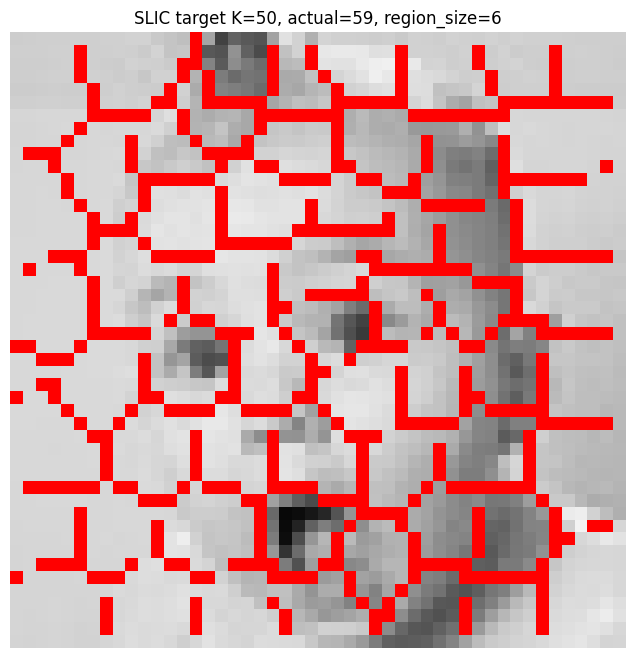

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1) Đọc ảnh
# img_bgr = cv2.imread("./mock-data/crop_0_200_180_480.png")
img_bgr = cv2.imread("./mock-data/Surprise_1359028.jpg")
if img_bgr is None:
    raise ValueError("Khong doc duoc anh")

h, w = img_bgr.shape[:2]
K = 50

# 2) Suy ra region_size từ K
region_size = max(4, int(np.sqrt((h * w) / K)))

# 3) Tạo SLIC (SLICO thường ổn định hơn)
slic = cv2.ximgproc.createSuperpixelSLIC(
    image=img_bgr,
    algorithm=cv2.ximgproc.SLICO,   # hoac cv2.ximgproc.SLIC
    region_size=region_size,
    ruler=10.0
)

# 4) Chạy lặp và hậu xử lý
slic.iterate(10)
slic.enforceLabelConnectivity(min_element_size=25)

labels = slic.getLabels()
k_real = slic.getNumberOfSuperpixels()
print("So superpixel thuc te:", k_real)

# 5) Vẽ biên superpixel
contour_mask = slic.getLabelContourMask(thick_line=True)
vis = img_bgr.copy()
vis[contour_mask == 255] = (0, 0, 255)  # do trong BGR

# 6) Hiển thị
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"SLIC target K={K}, actual={k_real}, region_size={region_size}")
plt.axis("off")
plt.show()